In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

In [10]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(url)

df_original = df.copy()

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [11]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [13]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Data Types:")
print(df.dtypes)
print("Missing Values:")
print(df.isnull().sum())
print("Dataset Information:")
df.info()

Number of rows: 299
Number of columns: 13
Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object
Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64
Dataset Information:
<class 'pandas.core.fram

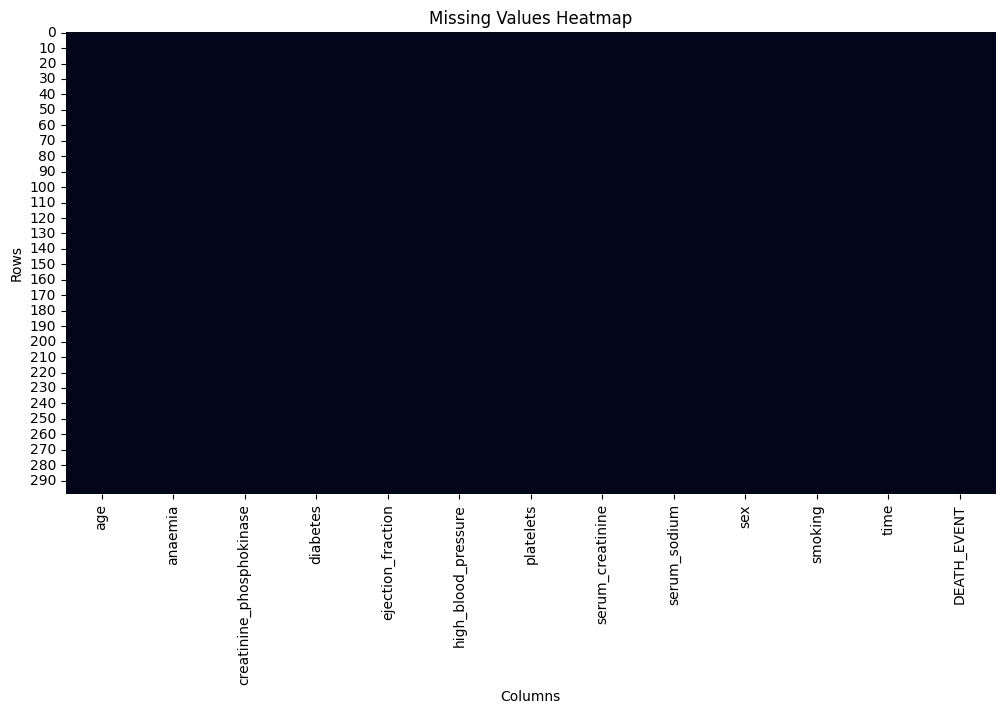

In [14]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

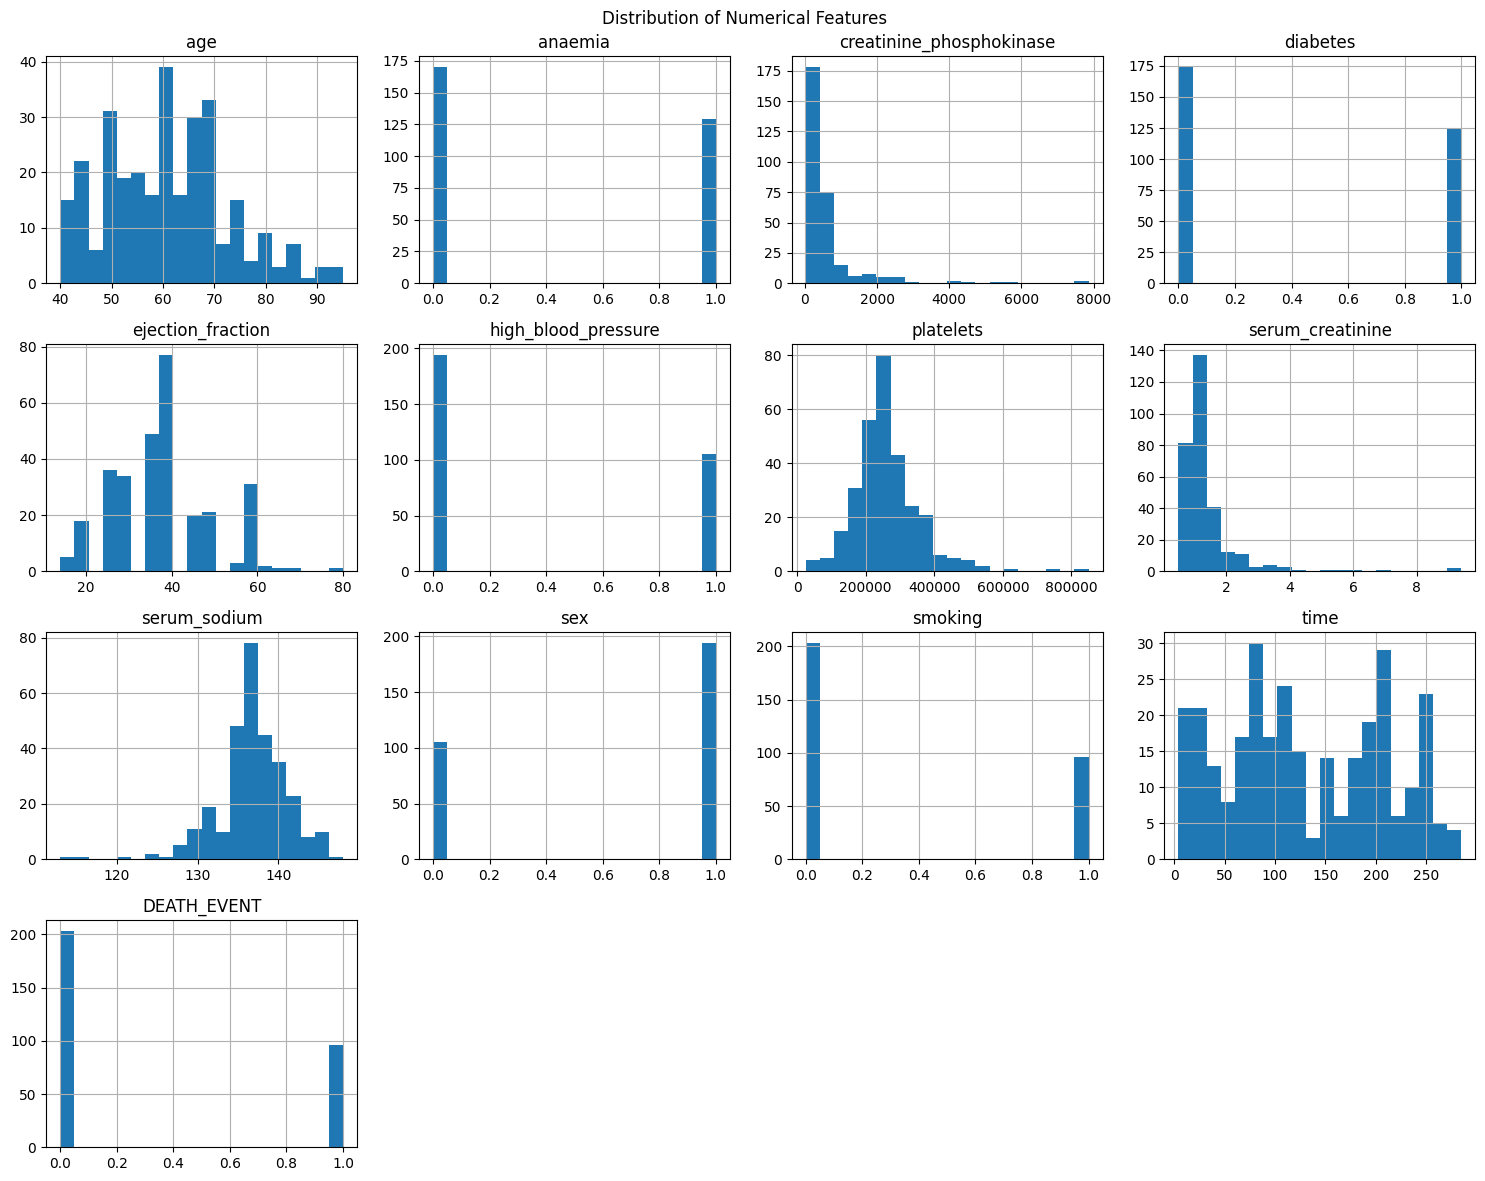

In [15]:
df.hist(figsize=(15, 12), bins=20)

plt.suptitle("Distribution of Numerical Features")

plt.tight_layout()
plt.show()

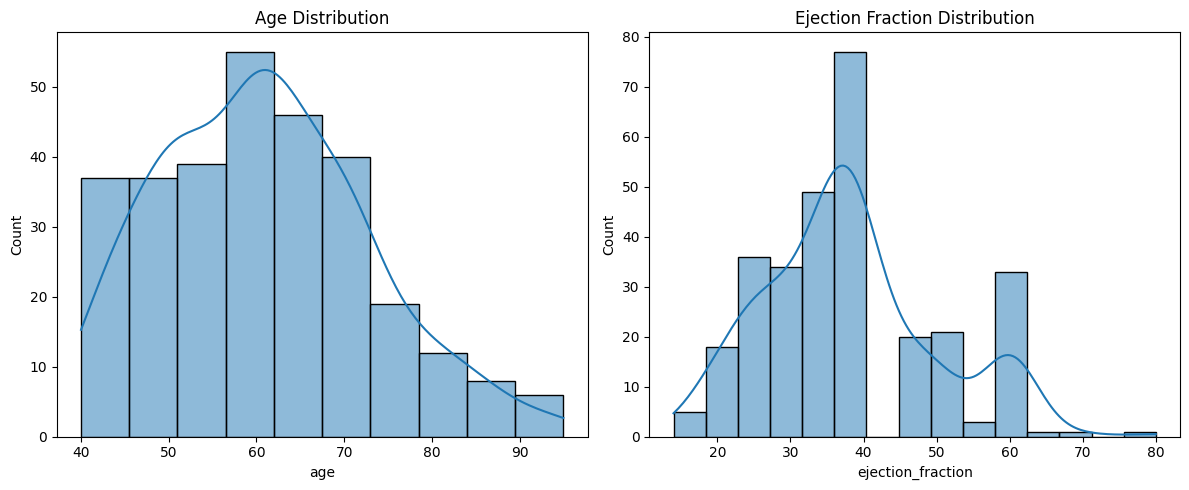

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")

plt.subplot(1, 2, 2)
sns.histplot(df["ejection_fraction"], kde=True)
plt.title("Ejection Fraction Distribution")

plt.tight_layout()
plt.show()

In [17]:
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')


In [21]:
for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [22]:
categorical_columns = df.select_dtypes(exclude=np.number).columns

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index([], dtype='object')


In [23]:
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [24]:
print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [25]:
outlier_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

In [26]:
for column in outlier_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[
        (df[column] >= lower_limit) &
        (df[column] <= upper_limit)
    ]

In [27]:
print("Rows after removing outliers:", df.shape[0])
print("Columns:", df.shape[1])

Rows after removing outliers: 224
Columns: 13


In [28]:
print("Minimum age:", df["age"].min())
print("Maximum age:", df["age"].max())
df.loc[df["age"] < 0, "age"] = df["age"].median()
print("Minimum ejection fraction:", df["ejection_fraction"].min())
print("Minimum serum creatinine:", df["serum_creatinine"].min())
print("Sex values:", df["sex"].unique())
print("Smoking values:", df["smoking"].unique())

Minimum age: 40.0
Maximum age: 95.0
Minimum ejection fraction: 14
Minimum serum creatinine: 0.6
Sex values: [1 0]
Smoking values: [0 1]


In [29]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 60, np.inf],
    labels=["<40", "40-60", ">60"],
    right=False
)
df[["age", "age_group"]].head(10)
ef_min = df["ejection_fraction"].min()
ef_max = df["ejection_fraction"].max()

creatinine_min = df["serum_creatinine"].min()
creatinine_max = df["serum_creatinine"].max()
df["ef_normalized"] = (
    (df["ejection_fraction"] - ef_min) /
    (ef_max - ef_min)
)

df["creatinine_normalized"] = (
    (df["serum_creatinine"] - creatinine_min) /
    (creatinine_max - creatinine_min)
)
df["risk_score"] = (
    (1 - df["ef_normalized"]) *
    df["creatinine_normalized"]
)
df[
    [
        "ejection_fraction",
        "serum_creatinine",
        "risk_score"
    ]
].head()

,ejection_fraction,serum_creatinine,risk_score
0,20,1.9,0.764706
2,20,1.3,0.411765
3,20,1.9,0.764706
5,40,2.1,0.490196
6,15,1.2,0.392157


In [33]:
for column in df.columns:

    if df[column].dtype == "bool":
        df[column] = df[column].astype(int)
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,ef_normalized,creatinine_normalized,risk_score,age_group_40-60,age_group_>60
0,75.0,0,582,0,20,1,265000.0,1.9,130,1,0,4,1,0.117647,0.866667,0.764706,0,1
2,65.0,0,146,0,20,0,162000.0,1.3,129,1,1,7,1,0.117647,0.466667,0.411765,0,1
3,50.0,1,111,0,20,0,210000.0,1.9,137,1,0,7,1,0.117647,0.866667,0.764706,1,0
5,90.0,1,47,0,40,1,204000.0,2.1,132,1,1,8,1,0.509804,1.000000,0.490196,0,1
6,75.0,1,246,0,15,0,127000.0,1.2,137,1,0,10,1,0.019608,0.400000,0.392157,0,1


Task 10 completed: Categorical variables encoded.
Task 11 completed: Numerical features normalized to 0-1.

========== SUMMARY STATISTICS AFTER CLEANING ==========

Mean:
age                         0.378355
anaemia                     0.468750
creatinine_phosphokinase    0.261896
diabetes                    0.419643
ejection_fraction           0.474090
high_blood_pressure         0.379464
platelets                   0.438902
serum_creatinine            0.352381
serum_sodium                0.523680
sex                         0.642857
smoking                     0.321429
time                        0.457836
DEATH_EVENT                 0.272321
ef_normalized               0.474090
creatinine_normalized       0.352381
risk_score                  0.195190
age_group_40-60             0.441964
age_group_>60               0.558036
dtype: float64

Median:
age                         0.363636
anaemia                     0.000000
creatinine_phosphokinase    0.155290
diabetes                    

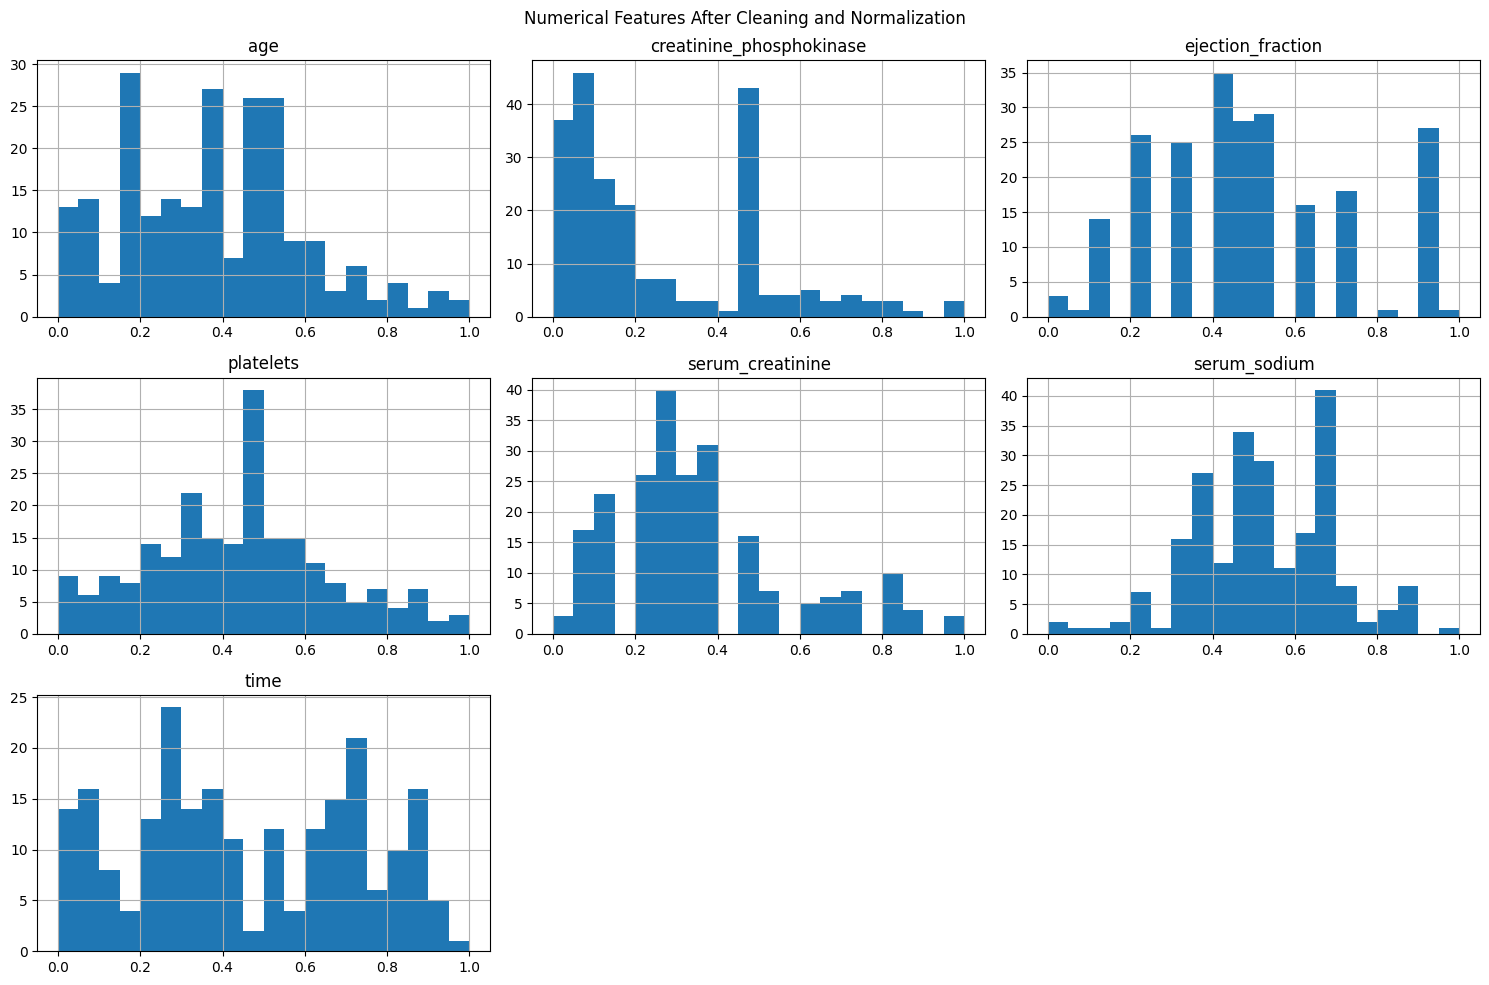

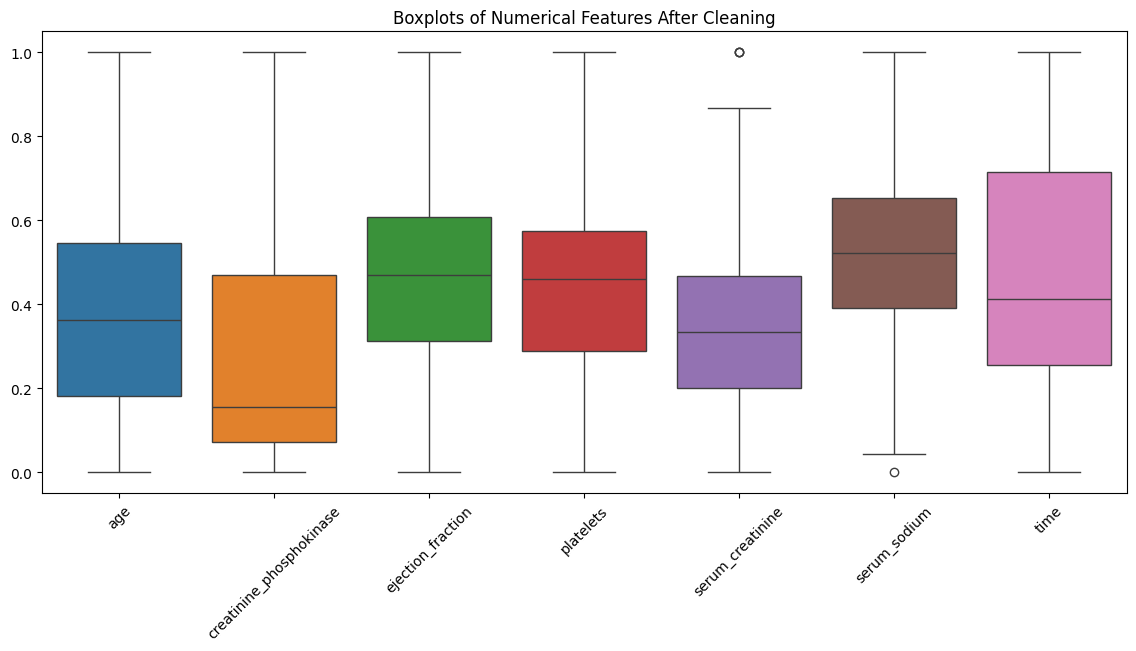

Task 13 completed: Cleaning validated using histograms and boxplots.

========== FINAL MISSING VALUE CHECK ==========
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
ef_normalized               0
creatinine_normalized       0
risk_score                  0
age_group_40-60             0
age_group_>60               0
dtype: int64

SUCCESS: No missing values remain.

========== FINAL CLEANED DATASET ==========
Final number of rows: 224
Final number of columns: 18


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,ef_normalized,creatinine_normalized,risk_score,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,1,0,0.000000,1,0.117647,0.866667,0.764706,0,1
2,0.454545,0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,1,1,0.010676,1,0.117647,0.466667,0.411765,0,1
3,0.181818,1,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,1,0,0.010676,1,0.117647,0.866667,0.764706,1,0
5,0.909091,1,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,1,1,0.014235,1,0.509804,1.000000,0.490196,0,1
6,0.636364,1,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,1,0,0.021352,1,0.019608,0.400000,0.392157,0,1



ASSIGNMENT COMPLETED SUCCESSFULLY!


In [34]:
if "age_group" in df.columns:
    df = pd.get_dummies(df, columns=["age_group"], drop_first=True)

# Convert True/False values to 0/1
for column in df.columns:
    if df[column].dtype == "bool":
        df[column] = df[column].astype(int)

print("Task 10 completed: Categorical variables encoded.")




from sklearn.preprocessing import MinMaxScaler

scale_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

scaler = MinMaxScaler()

df[scale_columns] = scaler.fit_transform(df[scale_columns])

print("Task 11 completed: Numerical features normalized to 0-1.")



print("\n========== SUMMARY STATISTICS AFTER CLEANING ==========")

print("\nMean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nStandard Deviation:")
print(df.std(numeric_only=True))


# ---------- TASK 13: VALIDATE CLEANING ----------

# Histograms
df[scale_columns].hist(
    figsize=(15, 10),
    bins=20
)

plt.suptitle("Numerical Features After Cleaning and Normalization")
plt.tight_layout()
plt.show()


# Boxplots
plt.figure(figsize=(14, 6))

sns.boxplot(data=df[scale_columns])

plt.title("Boxplots of Numerical Features After Cleaning")
plt.xticks(rotation=45)

plt.show()

print("Task 13 completed: Cleaning validated using histograms and boxplots.")




print("\n========== FINAL MISSING VALUE CHECK ==========")

print(df.isnull().sum())

total_missing = df.isnull().sum().sum()

if total_missing == 0:
    print("\nSUCCESS: No missing values remain.")
else:
    print("\nMissing values remaining:", total_missing)




print("\n========== FINAL CLEANED DATASET ==========")

print("Final number of rows:", df.shape[0])
print("Final number of columns:", df.shape[1])

display(df.head())

print("\nASSIGNMENT COMPLETED SUCCESSFULLY!")